In [4]:
## Preprocessing of the 3W Dataset

# This notebook demonstrates the preprocessing pipeline applied to the **3W dataset**
# (Petrobras offshore oil well data) in preparation for our models, decomposition and anomaly detection.

# The preprocessing is implemented as a reusable **RTDIP-compatible component**
# and validated on real 3W data.


In [8]:
import sys
from pathlib import Path

# Dynamically find repo root
current = Path().resolve()

while current.name != "amos2025ws03-rtdip-timeseries-forecasting":
    if current.parent == current:
        raise RuntimeError("Could not find repo root")
    current = current.parent

repo_root = current
sdk_path = repo_root / "src" / "sdk" / "python"

print("SDK path:", sdk_path)
print("Exists:", sdk_path.exists())

sys.path.insert(0, str(sdk_path))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rtdip_sdk.pipelines.preprocessing.three_w import ThreeWPreprocessing

sns.set_style("whitegrid")


SDK path: /Users/starbook/AMOS/amos2025ws03-rtdip-timeseries-forecasting/src/sdk/python
Exists: True


In [14]:
metrics_description = pd.DataFrame({
    "Feature": [
        "P-PDG",
        "P-TPT",
        "T-TPT",
        "P-MON-CKP",
        "T-JUS-CKP",
        "P-JUS-CKGL",
        "QGL",
        "class",
        "scenario_id",
        "well_file",
    ],
    "Description": [
        "Pressure at the Downhole Gauge (PDG)",
        "Pressure at the Tubing Head (TPT)",
        "Temperature at the Tubing Head (TPT)",
        "Pressure at the Choke Manifold",
        "Temperature at the Choke Manifold",
        "Pressure downstream of the choke (Gas Lift line)",
        "Gas Lift flow rate",
        "Operational state / fault label (0 = normal, >0 = fault)",
        "Scenario identifier (operating condition / fault scenario)",
        "Source CSV file (well and timestamp metadata)",
    ],
    "Unit / Type": [
        "Pressure (Pa)",
        "Pressure (Pa)",
        "Temperature (°C)",
        "Pressure (Pa)",
        "Temperature (°C)",
        "Pressure (Pa)",
        "Flow rate",
        "Categorical label",
        "Categorical",
        "Metadata",
    ]
})

metrics_description

,Feature,Description,Unit / Type
0,P-PDG,Pressure at the Downhole Gauge (PDG),Pressure (Pa)
1,P-TPT,Pressure at the Tubing Head (TPT),Pressure (Pa)
2,T-TPT,Temperature at the Tubing Head (TPT),Temperature (°C)
3,P-MON-CKP,Pressure at the Choke Manifold,Pressure (Pa)
4,T-JUS-CKP,Temperature at the Choke Manifold,Temperature (°C)
5,P-JUS-CKGL,Pressure downstream of the choke (Gas Lift line),Pressure (Pa)
6,QGL,Gas Lift flow rate,Flow rate
7,class,"Operational state / fault label (0 = normal, >...",Categorical label
8,scenario_id,Scenario identifier (operating condition / fau...,Categorical
9,well_file,Source CSV file (well and timestamp metadata),Metadata


In [19]:
# Instantiate the preprocessing component
component = ThreeWPreprocessing(
    data_path="/Users/starbook/AMOS/3w_dataset/data/data",  # local 3W dataset
    scenarios=None,
    missing_value_strategy="ffill",
)

# Run preprocessing
df = component.run()

# Preview result
df.head()




📂 Loading 3W dataset from: /Users/starbook/AMOS/3w_dataset/data/data
➡️ Scenario 0: 597 files
➡️ Scenario 1: 129 files
➡️ Scenario 2: 38 files
➡️ Scenario 3: 106 files
➡️ Scenario 4: 344 files
➡️ Scenario 5: 451 files
➡️ Scenario 6: 221 files
➡️ Scenario 7: 14 files
➡️ Scenario 8: 84 files


,timestamp,P-PDG,P-TPT,T-TPT,P-MON-CKP,T-JUS-CKP,P-JUS-CKGL,T-JUS-CKGL,QGL,class,scenario_id,well_file
0,2012-04-10 19:23:26,2.157054e+09,684335400.0,59.24538,1625144.0,NaN,1.551768e+09,NaN,0.056527,0.0,8,WELL-00020_20120410192326.csv
1,2012-04-10 19:23:27,2.157074e+09,684189700.0,59.27158,1623155.0,NaN,1.551785e+09,NaN,0.056532,0.0,8,WELL-00020_20120410192326.csv
2,2012-04-10 19:23:28,2.157094e+09,684043900.0,59.29778,1621166.0,NaN,1.551802e+09,NaN,0.056537,0.0,8,WELL-00020_20120410192326.csv
3,2012-04-10 19:23:29,2.157114e+09,683898200.0,59.32397,1619176.0,NaN,1.551819e+09,NaN,0.056542,0.0,8,WELL-00020_20120410192326.csv
4,2012-04-10 19:23:30,2.157134e+09,683752500.0,59.35017,1617187.0,NaN,1.551836e+09,NaN,0.056547,0.0,8,WELL-00020_20120410192326.csv


In [20]:
# Basic dataset overview
print("Dataset shape:", df.shape)

print("\nColumn types:")
display(df.dtypes)

print("\nMissing values per column:")
display(df.isna().sum())




Dataset shape: (50913215, 12)

Column types:


timestamp      datetime64[ns]
P-PDG                 float64
P-TPT                 float64
T-TPT                 float64
P-MON-CKP             float64
T-JUS-CKP             float64
P-JUS-CKGL            float64
T-JUS-CKGL            float64
QGL                   float64
class                 float64
scenario_id            object
well_file              object
dtype: object


Missing values per column:


timestamp             0
P-PDG                 0
P-TPT                 0
T-TPT                 0
P-MON-CKP             0
T-JUS-CKP         15688
P-JUS-CKGL            0
T-JUS-CKGL     50913215
QGL                   0
class                 0
scenario_id           0
well_file             0
dtype: int64

In [21]:
# Check timestamp ordering
is_sorted = df["timestamp"].is_monotonic_increasing
print("Timestamps are sorted chronologically:", is_sorted)

# Inspect timestamp range
print("Timestamp range:")
print("Start:", df["timestamp"].min())
print("End:  ", df["timestamp"].max())


Timestamps are sorted chronologically: True
Timestamp range:
Start: 2012-04-10 19:23:26
End:   2018-10-07 21:12:07


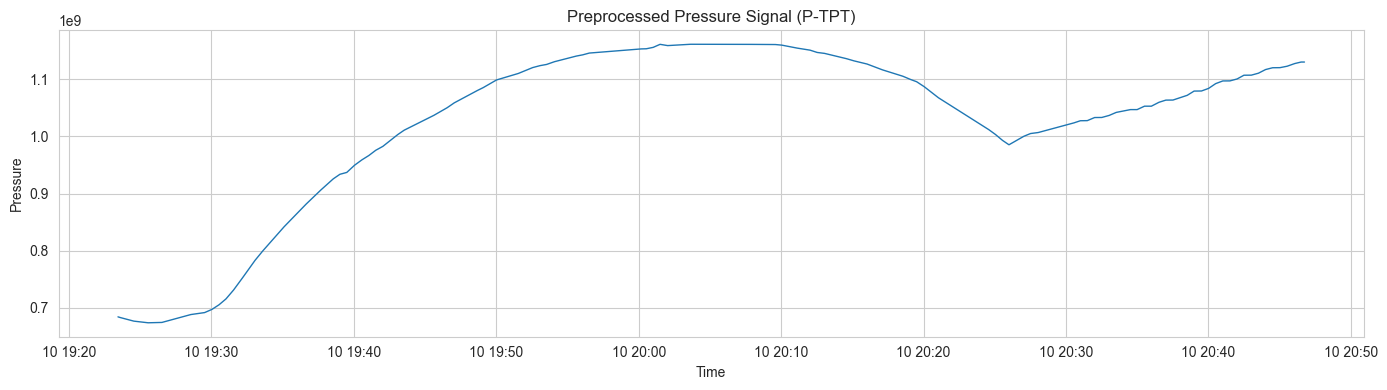

In [22]:
# Plot a sample of one signal to visually inspect preprocessing quality
sample_size = 5000  # keep it readable

plt.figure(figsize=(14, 4))
plt.plot(
    df["timestamp"].iloc[:sample_size],
    df["P-TPT"].iloc[:sample_size],
    linewidth=1
)

plt.title("Preprocessed Pressure Signal (P-TPT)")
plt.xlabel("Time")
plt.ylabel("Pressure")
plt.tight_layout()
plt.show()


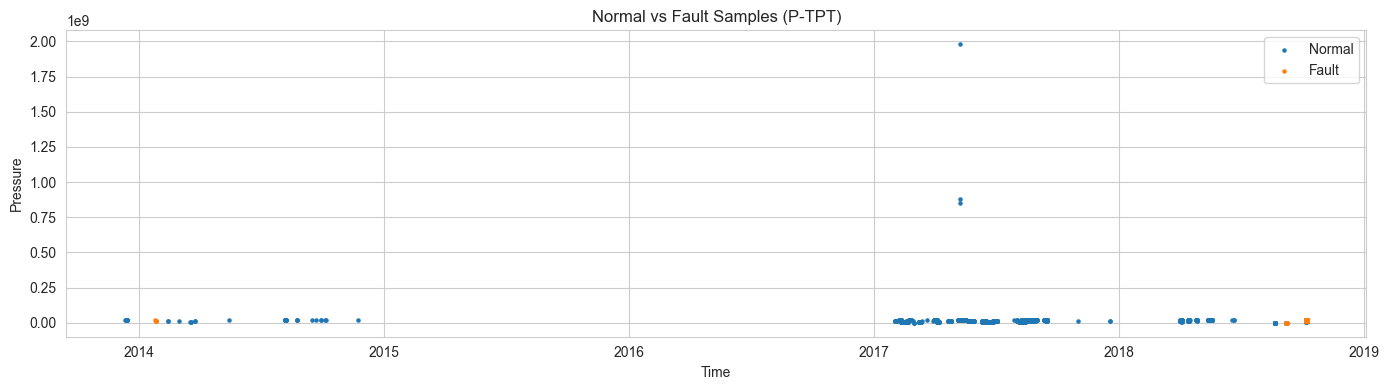

In [24]:
sample_fault = df[df["class"] == 1].sample(n=3000, random_state=42)
sample_normal = df[df["class"] == 0].sample(n=3000, random_state=42)

plt.figure(figsize=(14,4))
plt.scatter(sample_normal["timestamp"], sample_normal["P-TPT"], s=5, label="Normal")
plt.scatter(sample_fault["timestamp"], sample_fault["P-TPT"], s=5, label="Fault")

plt.legend()
plt.title("Normal vs Fault Samples (P-TPT)")
plt.xlabel("Time")
plt.ylabel("Pressure")
plt.tight_layout()
plt.show()
